--- Depth: 3 ---
Training Accuracy: 94.38%
Testing Accuracy : 92.50%
Classification Report:
               precision    recall  f1-score   support

        Fail       0.75      0.86      0.80         7
        Pass       0.97      0.94      0.95        33

    accuracy                           0.93        40
   macro avg       0.86      0.90      0.88        40
weighted avg       0.93      0.93      0.93        40

--- Depth: 4 ---
Training Accuracy: 98.75%
Testing Accuracy : 97.50%
Classification Report:
               precision    recall  f1-score   support

        Fail       1.00      0.86      0.92         7
        Pass       0.97      1.00      0.99        33

    accuracy                           0.97        40
   macro avg       0.99      0.93      0.95        40
weighted avg       0.98      0.97      0.97        40

--- Depth: 5 ---
Training Accuracy: 100.00%
Testing Accuracy : 95.00%
Classification Report:
               precision    recall  f1-score   support

        Fai

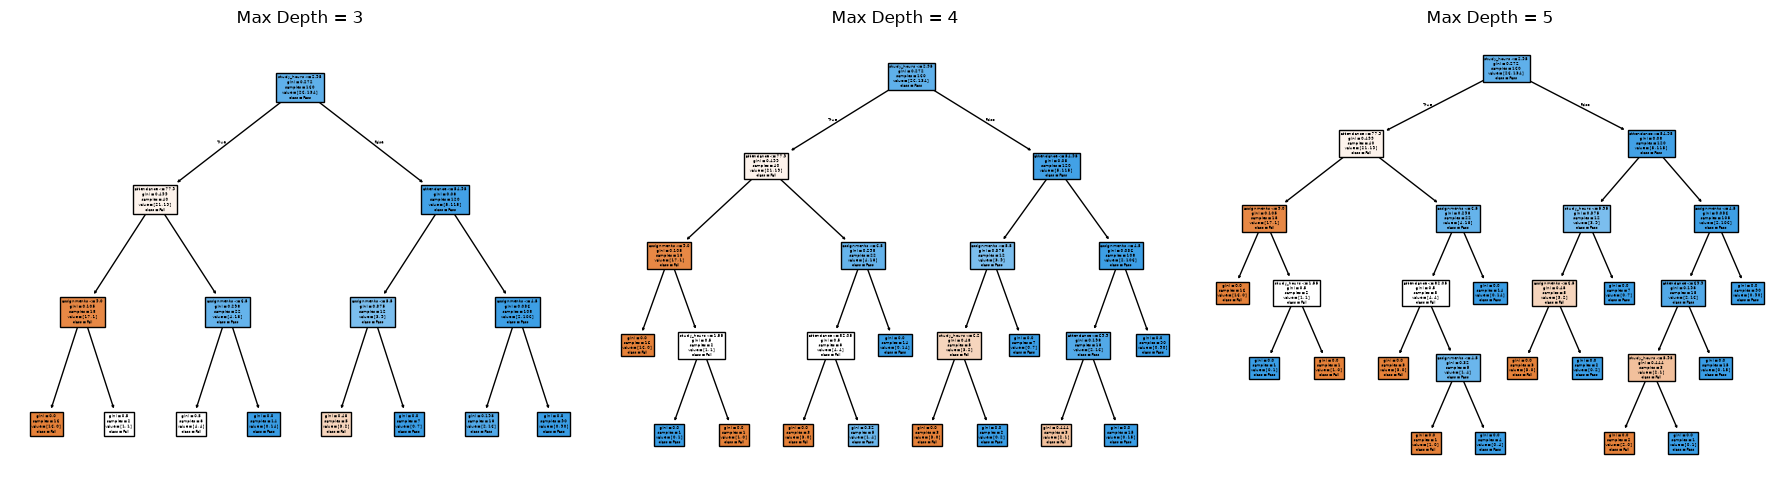

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
n_samples = 200

study_hours = np.round(np.random.uniform(1.0, 10.0, n_samples), 1)
attendance = np.round(np.random.uniform(50.0, 100.0, n_samples), 1)
assignments = np.random.randint(4, 11, n_samples)

performance_score = (study_hours * 0.4) + (attendance * 0.05) + (assignments * 0.3)
result = np.where(performance_score >= 6.5, "Pass", "Fail")

df = pd.DataFrame({
    'study_hours': study_hours,
    'attendance': attendance,
    'assignments': assignments,
    'result': result
})

X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

depths = [3, 4, 5]
results = {}

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    results[depth] = {
        'model': clf,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'report': classification_report(y_test, y_test_pred)
    }

for depth, metrics in results.items():
    print(f"--- Depth: {depth} ---")
    print(f"Training Accuracy: {metrics['train_acc'] * 100:.2f}%")
    print(f"Testing Accuracy : {metrics['test_acc'] * 100:.2f}%")
    print("Classification Report:\n", metrics['report'])
    print("=" * 40)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, depth in enumerate(depths):
    plot_tree(
        results[depth]['model'],
        feature_names=X.columns.tolist(),
        class_names=['Fail', 'Pass'],
        filled=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Max Depth = {depth}")
plt.tight_layout()
plt.show()

Transconductance Gain (Slope): 2.4565124503811333
Intercept: -1.9371795227202417
R2 Score: 0.9912100577202382
MSE: 0.07426276156000425


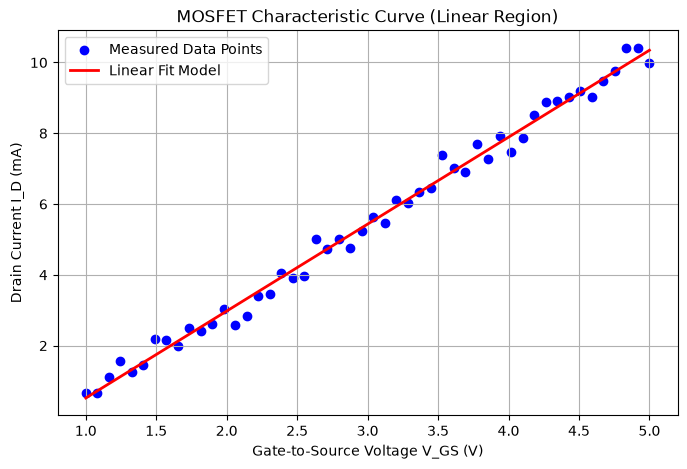

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
V_GS = np.linspace(1.0, 5.0, 50)
k = 2.5
V_th = 0.8
noise = np.random.normal(0, 0.3, size=V_GS.shape)

I_D = k * (V_GS - V_th) + noise

df_electronics = pd.DataFrame({'Gate_Voltage_V': V_GS, 'Drain_Current_mA': I_D})

X_elec = df_electronics[['Gate_Voltage_V']]
y_elec = df_electronics['Drain_Current_mA']

lr_model = LinearRegression()
lr_model.fit(X_elec, y_elec)

y_pred_elec = lr_model.predict(X_elec)

print("Transconductance Gain (Slope):", lr_model.coef_[0])
print("Intercept:", lr_model.intercept_)
print("R2 Score:", r2_score(y_elec, y_pred_elec))
print("MSE:", mean_squared_error(y_elec, y_pred_elec))

plt.figure(figsize=(8, 5))
plt.scatter(X_elec, y_elec, color='blue', label='Measured Data Points')
plt.plot(X_elec, y_pred_elec, color='red', linewidth=2, label='Linear Fit Model')
plt.xlabel('Gate-to-Source Voltage V_GS (V)')
plt.ylabel('Drain Current I_D (mA)')
plt.title('MOSFET Characteristic Curve (Linear Region)')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\bhard\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\bhard\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\bhard\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\bhard\anaconda3\Lib\subprocess.py", line 555, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^

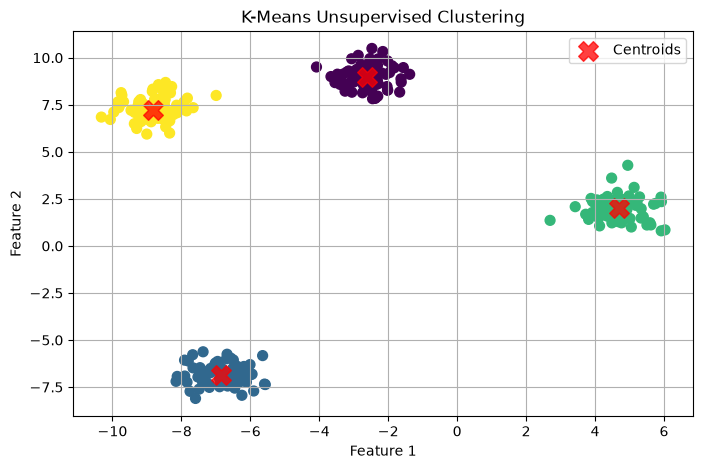

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X_unsupervised, _ = make_blobs(
    n_samples=300, 
    centers=4, 
    cluster_std=0.60, 
    random_state=42
)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_unsupervised)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 5))
plt.scatter(
    X_unsupervised[:, 0], 
    X_unsupervised[:, 1], 
    c=y_kmeans, 
    s=50, 
    cmap='viridis'
)
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    c='red', 
    s=200, 
    alpha=0.75, 
    marker='X', 
    label='Centroids'
)
plt.title('K-Means Unsupervised Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()